In [1]:

# 1. Import Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [2]:

# 2. Load the MNIST Dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


In [3]:

# 3. Preprocess the Dataset

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training range:", x_train.min(), "to", x_train.max())
print("Testing range:", x_test.min(), "to", x_test.max())


Training range: 0.0 to 1.0
Testing range: 0.0 to 1.0


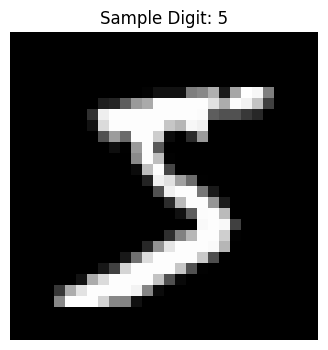

In [4]:

# 4. Display a Sample MNIST Image

plt.figure(figsize=(4, 4))
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Sample Digit: {y_train[0]}")
plt.axis("off")
plt.show()


In [5]:

# 5. Build the Original TensorFlow/Keras Model

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:

# 6. Compile the Model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [7]:

# 7. Train the Original Model

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1,
    verbose=1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9216 - loss: 0.2734 - val_accuracy: 0.9673 - val_loss: 0.1206
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9642 - loss: 0.1229 - val_accuracy: 0.9757 - val_loss: 0.0894
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9746 - loss: 0.0840 - val_accuracy: 0.9732 - val_loss: 0.0944
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9814 - loss: 0.0620 - val_accuracy: 0.9785 - val_loss: 0.0723
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9854 - loss: 0.0482 - val_accuracy: 0.9790 - val_loss: 0.0693


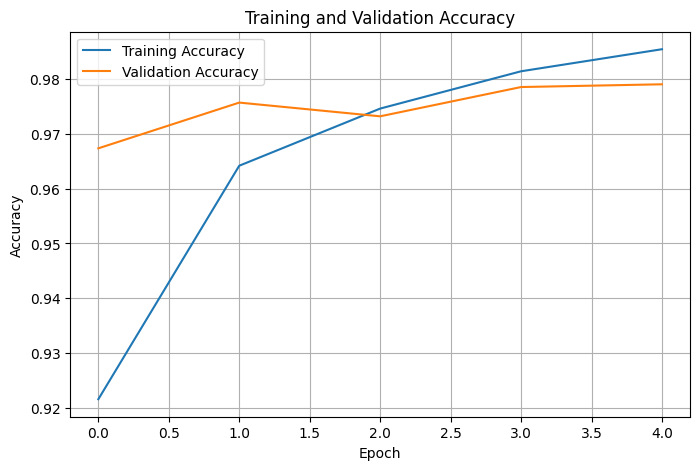

In [8]:

# 8. Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [9]:

# 9. Evaluate the Original TensorFlow Model

original_loss, original_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Original TensorFlow Accuracy: {original_accuracy * 100:.4f}%")


Original TensorFlow Accuracy: 97.6800%


In [10]:

# 10. Convert Original Model to TensorFlow Lite

converter = tf.lite.TFLiteConverter.from_keras_model(model)
original_tflite = converter.convert()

with open("original_model.tflite", "wb") as f:
    f.write(original_tflite)

print("Original TFLite model saved successfully.")


Saved artifact at '/tmp/tmpt3gl_k3f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134062428309648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134062428320016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134062428307728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134062428320592: TensorSpec(shape=(), dtype=tf.resource, name=None)
Original TFLite model saved successfully.


In [11]:

# 11. Measure Original TFLite Model Size

original_size = os.path.getsize("original_model.tflite")

print(f"Original TFLite Model Size: {original_size / 1024:.2f} KB")


Original TFLite Model Size: 400.11 KB


In [12]:

# 12. Create the Original TFLite Interpreter

original_interpreter = tf.lite.Interpreter(model_path="original_model.tflite")
original_interpreter.allocate_tensors()

original_input_details = original_interpreter.get_input_details()
original_output_details = original_interpreter.get_output_details()

print("Input Details:")
print(original_input_details)

print("\nOutput Details:")
print(original_output_details)


Input Details:
[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 28, 28], dtype=int32), 'shape_signature': array([-1, 28, 28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output Details:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 14, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [13]:

# 13. Test Original Model Inference

sample = x_test[0:1]

original_interpreter.set_tensor(
    original_input_details[0]["index"],
    sample
)

original_interpreter.invoke()

output = original_interpreter.get_tensor(
    original_output_details[0]["index"]
)

original_prediction = np.argmax(output)

print("Actual Label:", y_test[0])
print("Original Prediction:", original_prediction)


Actual Label: 7
Original Prediction: 7


In [14]:

# 14. Measure Original Model Inference Latency

# Multiple runs reduce the effect of one-time startup overhead.
num_runs = 100

start_time = time.perf_counter()

for _ in range(num_runs):
    original_interpreter.set_tensor(
        original_input_details[0]["index"],
        sample
    )
    original_interpreter.invoke()

end_time = time.perf_counter()

original_latency = ((end_time - start_time) / num_runs) * 1000

print(f"Original Average Latency: {original_latency:.4f} ms")


Original Average Latency: 0.0358 ms


In [15]:

# 15. Apply Post-Training Quantization

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

quantized_tflite = converter.convert()

with open("quantized_model.tflite", "wb") as f:
    f.write(quantized_tflite)

print("Quantized model saved successfully.")


Saved artifact at '/tmp/tmphvu0gz1j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134062428309648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134062428320016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134062428307728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134062428320592: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized model saved successfully.


In [16]:

# 16. Measure Quantized Model Size

quantized_size = os.path.getsize("quantized_model.tflite")

print(f"Quantized Model Size: {quantized_size / 1024:.2f} KB")


Quantized Model Size: 104.08 KB


In [17]:

# 17. Calculate Model Size Reduction

size_reduction = (
    (original_size - quantized_size) / original_size
) * 100

print(f"Model Size Reduction: {size_reduction:.2f}%")


Model Size Reduction: 73.99%


In [18]:

# 18. Load the Quantized Model

quantized_interpreter = tf.lite.Interpreter(
    model_path="quantized_model.tflite"
)

quantized_interpreter.allocate_tensors()

quantized_input_details = quantized_interpreter.get_input_details()
quantized_output_details = quantized_interpreter.get_output_details()

print("Input Details:")
print(quantized_input_details)

print("\nOutput Details:")
print(quantized_output_details)


Input Details:
[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 28, 28], dtype=int32), 'shape_signature': array([-1, 28, 28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output Details:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 14, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [19]:

# 19. Perform Inference Using Quantized Model

quantized_interpreter.set_tensor(
    quantized_input_details[0]["index"],
    sample
)

quantized_interpreter.invoke()

quantized_output = quantized_interpreter.get_tensor(
    quantized_output_details[0]["index"]
)

quantized_prediction = np.argmax(quantized_output)

print("Actual Label:", y_test[0])
print("Quantized Prediction:", quantized_prediction)


Actual Label: 7
Quantized Prediction: 7


In [20]:

# 20. Measure Quantized Model Latency

start_time = time.perf_counter()

for _ in range(num_runs):
    quantized_interpreter.set_tensor(
        quantized_input_details[0]["index"],
        sample
    )
    quantized_interpreter.invoke()

end_time = time.perf_counter()

quantized_latency = ((end_time - start_time) / num_runs) * 1000

print(f"Quantized Average Latency: {quantized_latency:.4f} ms")


Quantized Average Latency: 0.0432 ms


In [21]:

# 21. Evaluate Quantized Model Accuracy on the Complete Test Set

correct = 0
total = len(x_test)

for i in range(total):
    input_data = x_test[i:i+1]

    quantized_interpreter.set_tensor(
        quantized_input_details[0]["index"],
        input_data
    )

    quantized_interpreter.invoke()

    output = quantized_interpreter.get_tensor(
        quantized_output_details[0]["index"]
    )

    prediction = np.argmax(output)

    if prediction == y_test[i]:
        correct += 1

quantized_accuracy = correct / total

print(f"Quantized Model Accuracy: {quantized_accuracy * 100:.4f}%")


Quantized Model Accuracy: 97.6900%


In [22]:

# 22. Calculate Accuracy Difference

accuracy_difference = (
    original_accuracy - quantized_accuracy
) * 100

print(
    f"Accuracy Difference: {accuracy_difference:.4f} percentage points"
)


Accuracy Difference: -0.0100 percentage points


In [23]:

# 23. Calculate Latency Change

latency_change = (
    (original_latency - quantized_latency) / original_latency
) * 100

print(f"Latency Change: {latency_change:.2f}%")
print("Positive value = quantized model was faster in this measurement.")
print("Negative value = quantized model was slower in this measurement.")


Latency Change: -20.68%
Positive value = quantized model was faster in this measurement.
Negative value = quantized model was slower in this measurement.


In [24]:

# 24. Final Model Comparison

print("\n" + "=" * 55)
print("MODEL OPTIMIZATION RESULTS")
print("=" * 55)

print(f"\nOriginal Model Size   : {original_size / 1024:.2f} KB")
print(f"Quantized Model Size  : {quantized_size / 1024:.2f} KB")
print(f"Size Reduction       : {size_reduction:.2f}%")

print(f"\nOriginal Accuracy     : {original_accuracy * 100:.4f}%")
print(f"Quantized Accuracy    : {quantized_accuracy * 100:.4f}%")
print(f"Accuracy Difference   : {accuracy_difference:.4f} percentage points")

print(f"\nOriginal Latency      : {original_latency:.4f} ms")
print(f"Quantized Latency     : {quantized_latency:.4f} ms")
print(f"Latency Change        : {latency_change:.2f}%")

print("\n" + "=" * 55)



MODEL OPTIMIZATION RESULTS

Original Model Size   : 400.11 KB
Quantized Model Size  : 104.08 KB
Size Reduction       : 73.99%

Original Accuracy     : 97.6800%
Quantized Accuracy    : 97.6900%
Accuracy Difference   : -0.0100 percentage points

Original Latency      : 0.0358 ms
Quantized Latency     : 0.0432 ms
Latency Change        : -20.68%



In [25]:

# 25. Comparison Table

import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Model Size (KB)",
        "Accuracy (%)",
        "Average Latency (ms)"
    ],
    "Original TFLite Model": [
        original_size / 1024,
        original_accuracy * 100,
        original_latency
    ],
    "Quantized TFLite Model": [
        quantized_size / 1024,
        quantized_accuracy * 100,
        quantized_latency
    ]
})

comparison["Change"] = [
    f"{size_reduction:.2f}% reduction",
    f"{accuracy_difference:.4f} percentage points",
    f"{latency_change:.2f}%"
]

comparison


,Metric,Original TFLite Model,Quantized TFLite Model,Change
0,Model Size (KB),400.105469,104.078125,73.99% reduction
1,Accuracy (%),97.680002,97.690000,-0.0100 percentage points
2,Average Latency (ms),0.035837,0.043249,-20.68%



## Observation

Record the values produced by your Colab run:

| Parameter | Original TFLite Model | Quantized TFLite Model |
|---|---:|---:|
| Model size | Actual value | Actual value |
| Accuracy | Actual value | Actual value |
| Average latency | Actual value | Actual value |
| Size reduction | — | Actual % |
| Accuracy difference | — | Actual percentage points |
| Latency change | — | Actual % |

The exact values are expected to depend on the TensorFlow version, CPU/runtime, model architecture, and execution environment.
